# Recovering Bursty Star Formation Histories

The core capability of tengri: recovering bursty SFH features that
parametric models miss. Plus the "wrong model trap" — fitting a bursty
galaxy with a smooth model looks fine in chi-squared but gives wrong SFRs.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    Observation,
    Parameters,
    Photometry,
    Uniform,
    load_ssp_data,
)
from tengri.models.observation import Spectroscopy

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("demonstrations", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
FILTER_NAMES = ["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]
obs_spec = Observation(spectroscopy=Spectroscopy(wave_obs=WAVE_OBS))
obs_joint = Observation(
    photometry=Photometry.from_names(FILTER_NAMES),
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS),
)

## The Four Burstiness Regimes

| Regime | σ_PS | τ_PS | Physical analogy |
|--------|------|------|-----------------|
| Smooth | 0.3 | 100 Myr | Secular disk evolution |
| Moderate | 1.0 | 50 Myr | Gas cycling, minor mergers |
| Bursty | 2.0 | 20 Myr | SN feedback dominance |
| Extreme | 3.0 | 5 Myr | Dwarf starburst, first galaxies |

In [3]:
REGIMES = [
    {"sigma": 0.3, "tau": 100, "label": "Smooth"},
    {"sigma": 1.0, "tau": 50, "label": "Moderate"},
    {"sigma": 2.0, "tau": 20, "label": "Bursty"},
    {"sigma": 3.0, "tau": 5, "label": "Extreme"},
]

spec_stoch = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    sfh_field_psd_sigma=Uniform(0.1, 4.0),
    sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type=["tsnorm", "field"],
    n_grid=128,
)
model_stoch = Model(spec_stoch, ssp_data, observation=obs_spec)

W0325 13:29:26.399666 20322885 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
<local>/Projects/diffsed/src/tengri/core/model.py:466: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


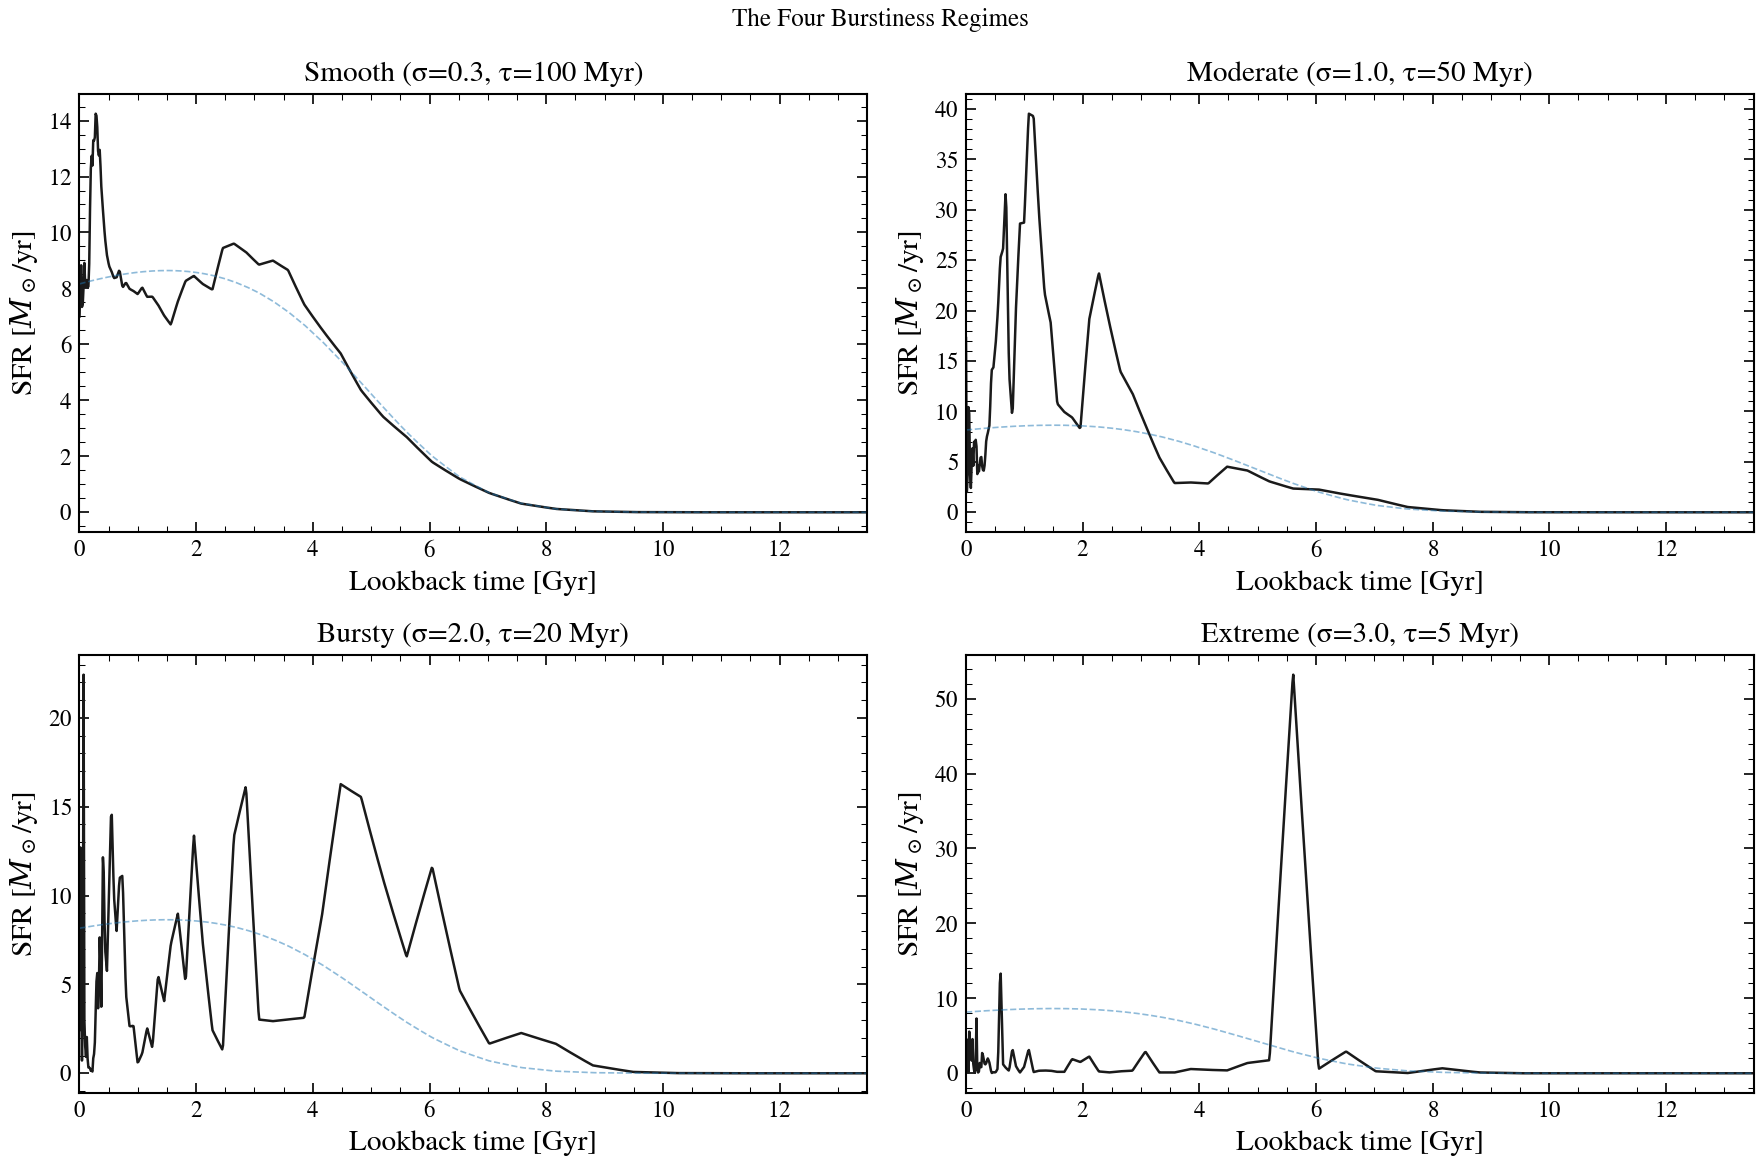

In [4]:
# --- FIGURE 1: 2×2 SFH showcase ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
regime_data = {}

for ax, reg in zip(axes.flat, REGIMES):
    key = jax.random.PRNGKey(abs(hash(reg["label"])) % 2**31)
    true_p = spec_stoch.sample(key)
    # Override to a typical star-forming galaxy with regime-specific burstiness
    true_p = {**true_p}
    true_p["sfh_tsnorm_log_peak_sfr"] = jnp.array(1.2)
    true_p["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(3.0)
    true_p["sfh_tsnorm_width_gyr"] = jnp.array(3.0)
    true_p["sfh_tsnorm_skew"] = jnp.array(0.3)
    true_p["sfh_tsnorm_trunc"] = jnp.array(2.0)
    true_p["sfh_field_psd_sigma"] = jnp.array(reg["sigma"])
    true_p["sfh_field_psd_tau_myr"] = jnp.array(float(reg["tau"]))

    sfh = model_stoch.predict_sfh(true_p)
    t_gyr = np.array(sfh["t_gyr"])
    sfr_full = np.array(sfh["sfr_full"])
    sfr_mean = np.array(sfh["sfr_mean"])

    ax.plot(t_gyr, sfr_full, color=COLORS["truth"], lw=1.2)
    ax.plot(t_gyr, sfr_mean, color=COLORS["sfh_mean"], lw=0.8, ls="--", alpha=0.5)
    ax.set_xlim(0, 13.5)
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel(r"SFR [$M_\odot$/yr]")
    ax.set_title(f"{reg['label']} (σ={reg['sigma']}, τ={reg['tau']} Myr)")

    regime_data[reg["label"]] = {"params": true_p, "sfh": sfh}

fig.suptitle("The Four Burstiness Regimes", fontsize=12)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_burstiness_regimes.png"), dpi=150, bbox_inches="tight")
plt.show()

## Recovery from Spectroscopy

In [5]:
# Fit each regime
regime_results = {}
for reg in REGIMES:
    true_p = regime_data[reg["label"]]["params"]
    mock = model_stoch.mock_spectrum(
        true_p,
        WAVE_OBS,
        snr=30.0,
        key=jax.random.PRNGKey(abs(hash(reg["label"])) % 2**31 + 1),
    )
    fitter = Fitter(model_stoch, mock.flux_obs, mock.noise)
    _ = fitter.run("map", n_steps=1000, verbose=False)
    res = fitter.run(
        "vi",
        n_iterations=15,
        n_samples=6,
        n_seeds=3,
        n_posterior_samples=2000,
        verbose=False,
    )
    regime_results[reg["label"]] = res
    print(f"  {reg['label']}: {res.wall_time_s:.1f}s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


  Smooth: 117.3s


assuming the specified inverse covariance is diagonal


...

<local>/Projects/diffsed/src/tengri/inference/fitter.py:2134: UserWarning: Seeds disagree: H = 189.0 ± 36.2 (CV=19%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_native_vi(


  Bursty: 123.7s


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


  Extreme: 108.8s


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_37684/1789944392.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


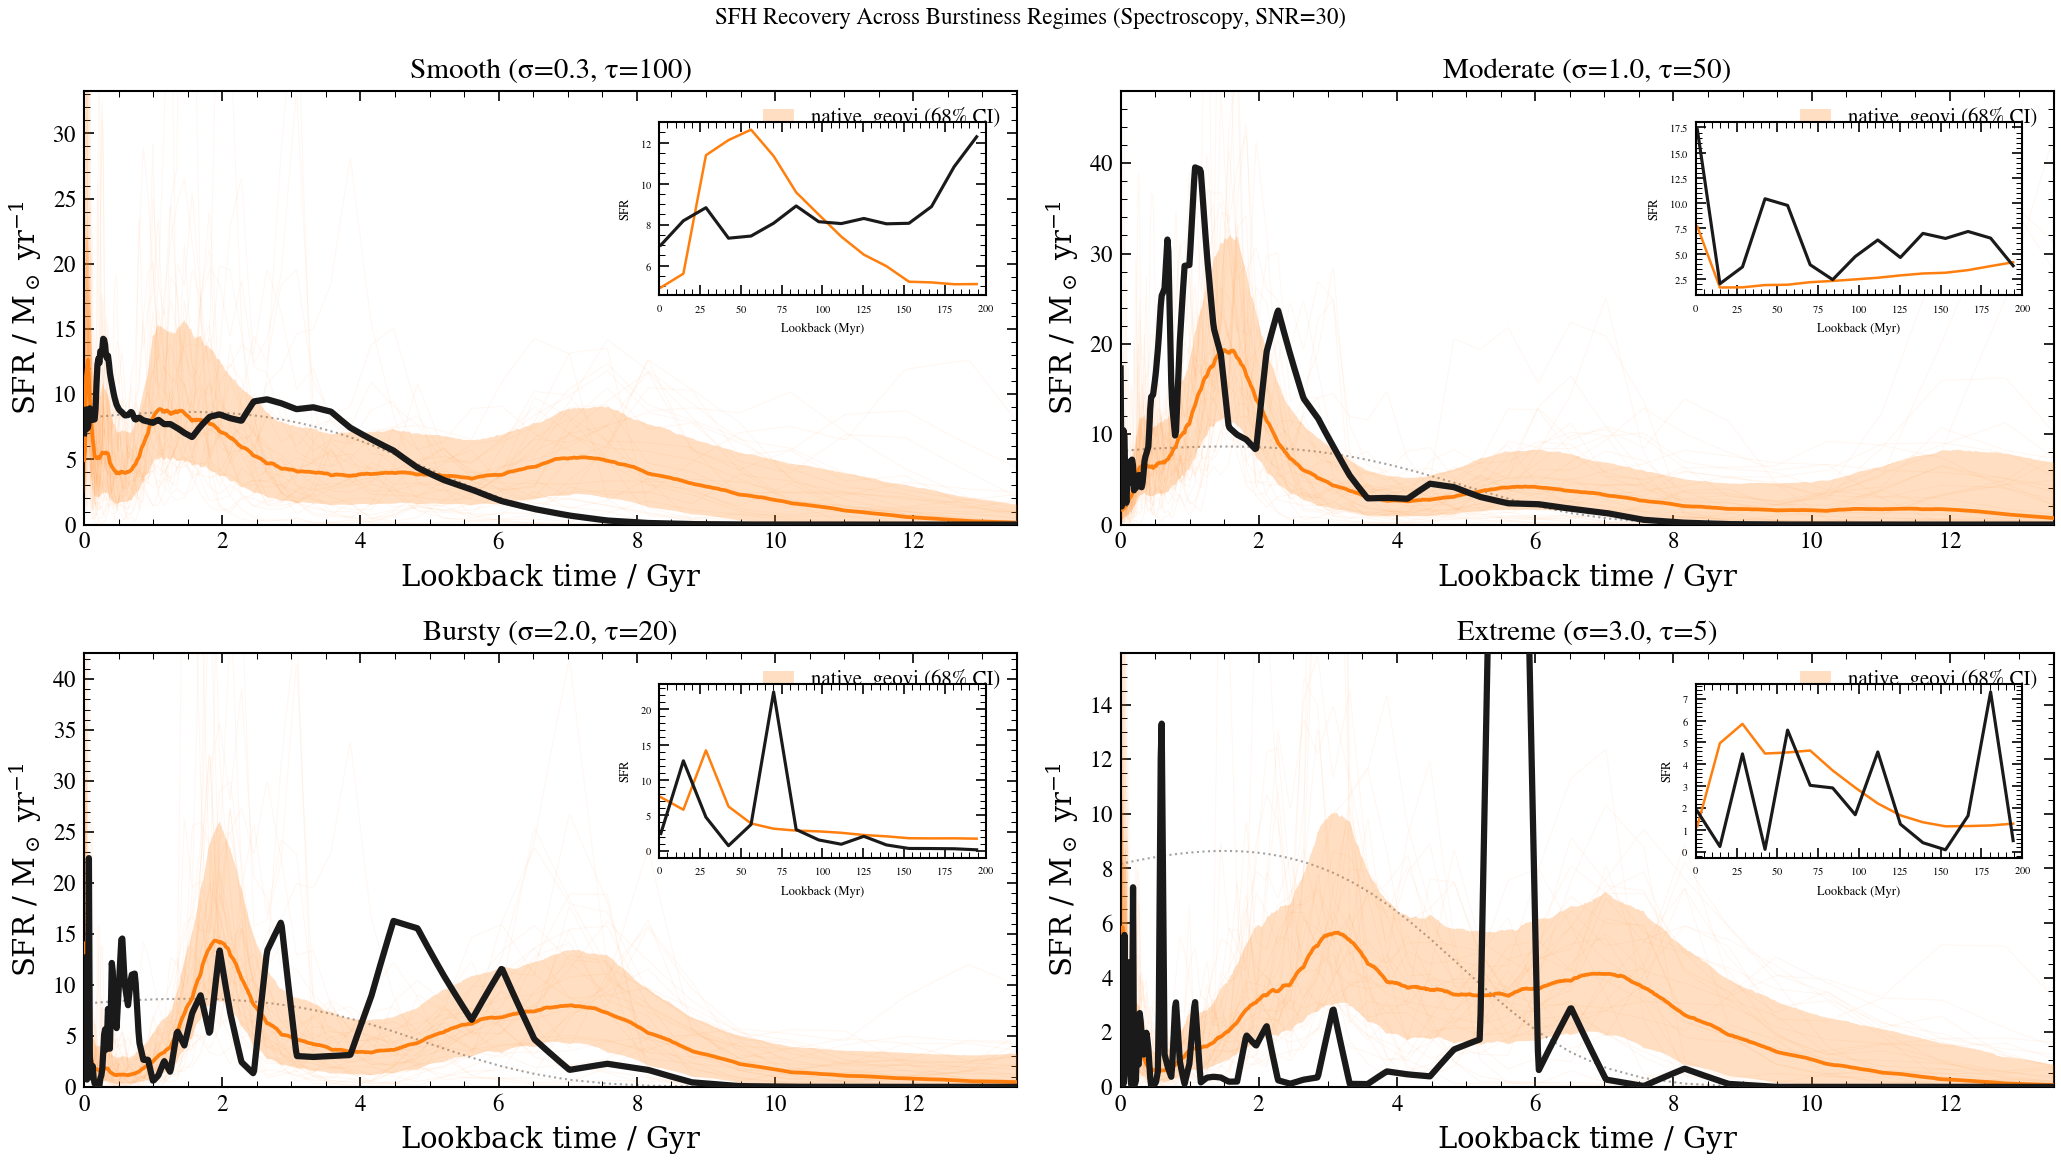

In [6]:
# --- FIGURE 2: 4-panel SFH recovery ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, reg in zip(axes.flat, REGIMES):
    true_p = regime_data[reg["label"]]["params"]
    plot_sfh(
        model_stoch,
        regime_results[reg["label"]],
        true_params=true_p,
        ax=ax,
        color=COLORS["geovi"],
        label="vi",
        method="geoVI",
        show_mean_sfh=True,
    )
    ax.set_title(f"{reg['label']} (σ={reg['sigma']}, τ={reg['tau']})")

fig.suptitle("SFH Recovery Across Burstiness Regimes (Spectroscopy, SNR=30)", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig02_sfh_recovery_4regimes.png"), dpi=150, bbox_inches="tight")
plt.show()

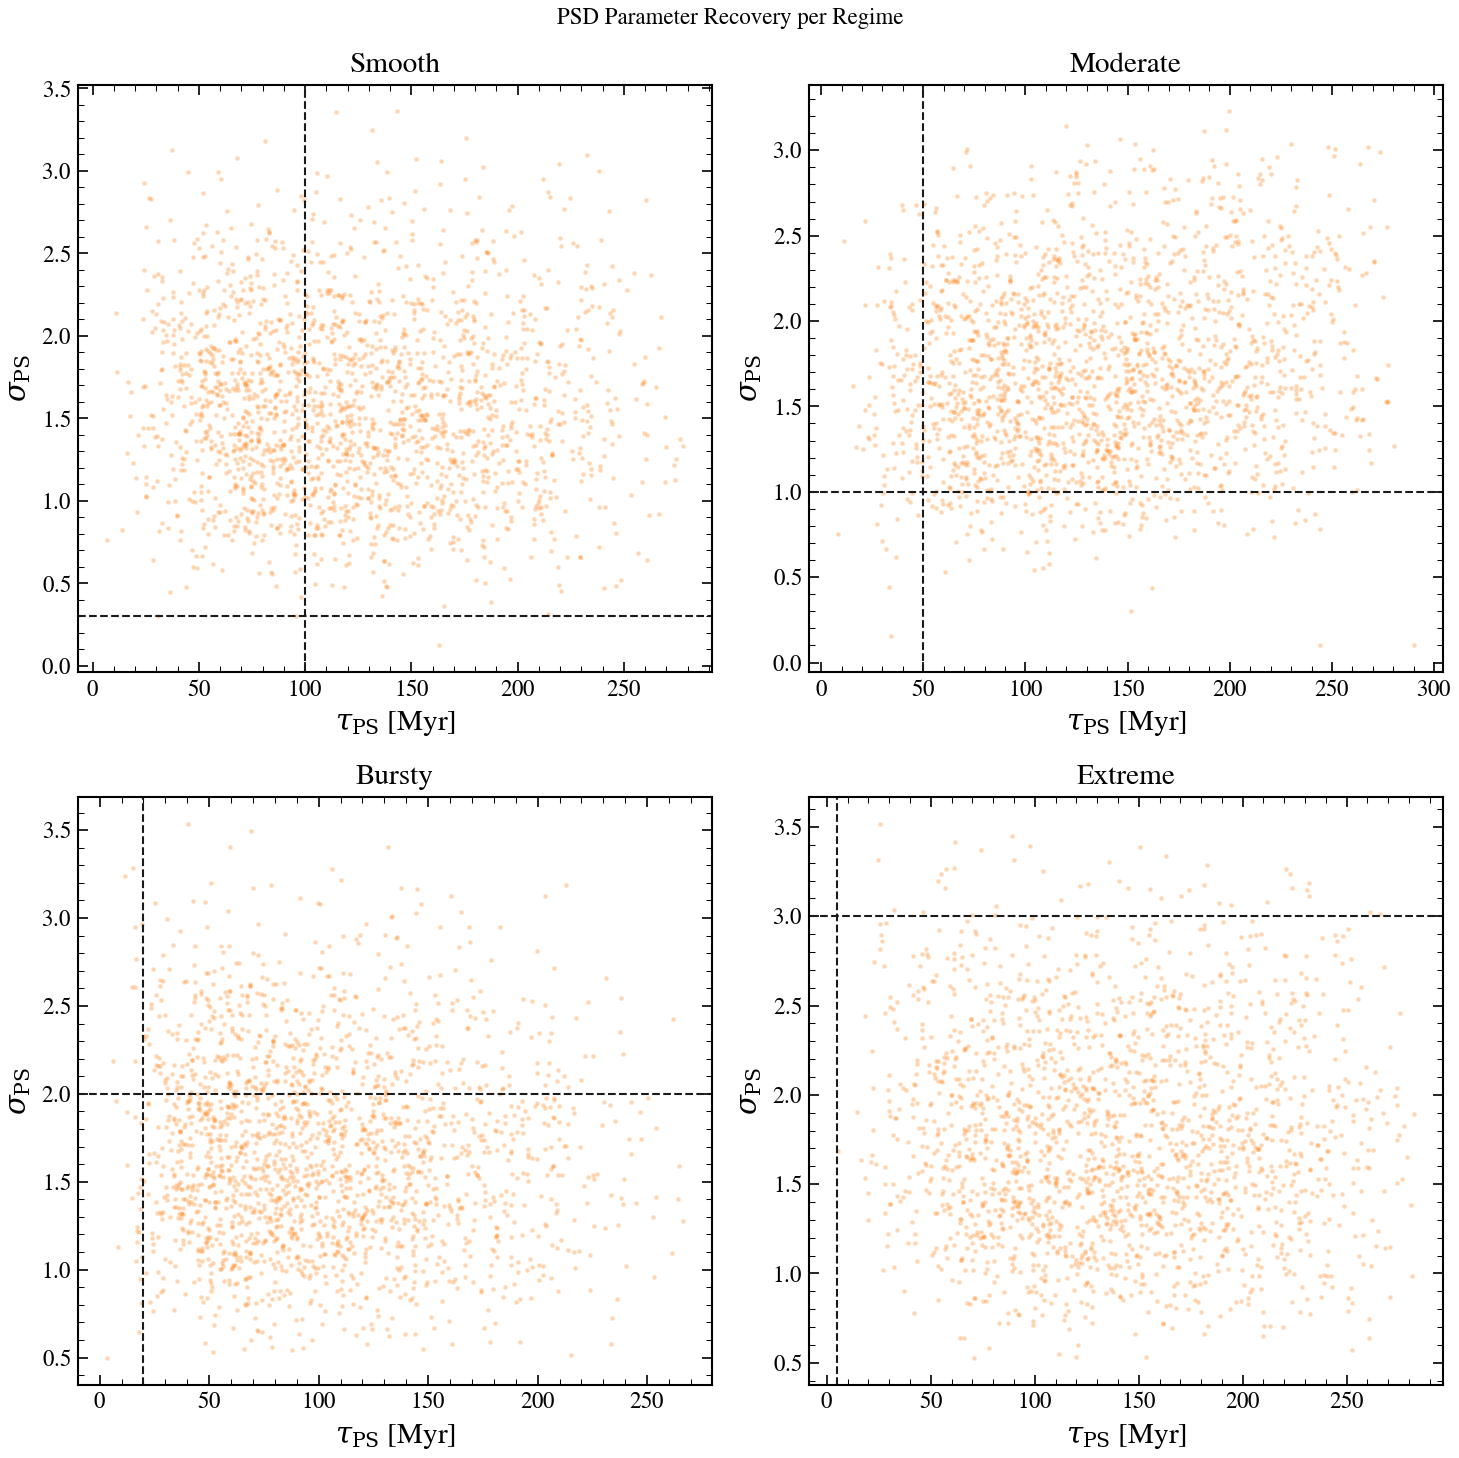

In [7]:
# --- FIGURE 3: PSD corner per regime ---
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
psd_params = ["sfh_field_psd_sigma", "sfh_field_psd_tau_myr"]
for ax, reg in zip(axes.flat, REGIMES):
    res = regime_results[reg["label"]]
    true_p = regime_data[reg["label"]]["params"]
    sig_s = np.array(res.samples["sfh_field_psd_sigma"])
    tau_s = np.array(res.samples["sfh_field_psd_tau_myr"])
    ax.scatter(tau_s, sig_s, s=2, alpha=0.2, color=COLORS["geovi"])
    ax.axhline(float(true_p["sfh_field_psd_sigma"]), color=COLORS["truth"], ls="--", lw=1)
    ax.axvline(float(true_p["sfh_field_psd_tau_myr"]), color=COLORS["truth"], ls="--", lw=1)
    ax.set_xlabel(r"$\tau_{\rm PS}$ [Myr]")
    ax.set_ylabel(r"$\sigma_{\rm PS}$")
    ax.set_title(reg["label"])

fig.suptitle("PSD Parameter Recovery per Regime", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_psd_corners.png"), dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Convergence diagnostics — all four regimes
print(convergence_table(regime_results, verbose=True))

Method           ESS min  ESS med   Accept   Diverg     Status
--------------------------------------------------------------
Smooth              1730     2000        —        —         OK
Moderate            1754     2000        —        —         OK
Bursty              1696     2000        —        —         OK
Extreme             1740     2000        —        —         OK
{'Smooth': {'ess_min': np.float64(1730.062685543809), 'ess_median': 2000.0, 'n_params_low_ess': 0, 'converged': True, 'warnings': []}, 'Moderate': {'ess_min': np.float64(1753.8485609282975), 'ess_median': 2000.0, 'n_params_low_ess': 0, 'converged': True, 'warnings': []}, 'Bursty': {'ess_min': np.float64(1696.03442654844), 'ess_median': 2000.0, 'n_params_low_ess': 0, 'converged': True, 'warnings': []}, 'Extreme': {'ess_min': np.float64(1739.7809899999452), 'ess_median': 2000.0, 'n_params_low_ess': 0, 'converged': True, 'warnings': []}}


In [9]:
# Parameter recovery table — Bursty regime (physical params only)
bursty_res = regime_results["Bursty"]
bursty_params = regime_data["Bursty"]["params"]
phys_params = [p for p in spec_stoch.free_params if "xi" not in p]
print(f"\n{'Parameter':<32s} {'True':>8s} {'Median':>8s} {'16%':>8s} {'84%':>8s} {'Status':>6s}")
print("-" * 76)
for name in phys_params:
    truth = float(bursty_params[name])
    lo, med, hi = np.percentile(bursty_res.samples[name], [16, 50, 84])
    covered = "ok" if lo <= truth <= hi else "MISS"
    print(f"  {name:<30s} {truth:8.3f} {med:8.3f} {lo:8.3f} {hi:8.3f} {covered:>6s}")


Parameter                            True   Median      16%      84% Status
----------------------------------------------------------------------------
  dust_tau_bc                       0.224    0.134    0.069    0.241     ok
  dust_tau_diff                     0.244    0.330    0.260    0.409   MISS
  met_logzsol                      -0.691   -1.380   -1.493   -1.252   MISS
  sfh_field_psd_sigma               2.000    1.646    1.133    2.235     ok
  sfh_field_psd_tau_myr            20.000   95.454   49.478  158.807   MISS
  sfh_tsnorm_log_peak_sfr           1.200    1.791    1.422    2.142   MISS
  sfh_tsnorm_peak_lbt_gyr           3.000    5.599    3.680    7.989   MISS
  sfh_tsnorm_skew                   0.300   -0.027   -0.587    0.323     ok
  sfh_tsnorm_trunc                  2.000    2.149    1.463    3.496     ok
  sfh_tsnorm_width_gyr              3.000    3.427    2.429    4.291     ok


## Elliptical Slice Sampling vs geoVI: Bursty Regime

ESS (Murray, Adams & MacKay 2010) is an exact MCMC method for models with
Gaussian priors on latent variables. It proposes along prior ellipses — no
step-size tuning. We compare it to geoVI on the "Bursty" regime (σ=2, τ=20 Myr).

In [10]:
bursty_mock_ess = model_stoch.mock_spectrum(
    regime_data["Bursty"]["params"],
    WAVE_OBS,
    snr=30.0,
    key=jax.random.PRNGKey(abs(hash("Bursty")) % 2**31 + 1),
)
fitter_ess = Fitter(model_stoch, bursty_mock_ess.flux_obs, bursty_mock_ess.noise)
_ = fitter_ess.run("map", n_steps=1000, verbose=False)
result_ess = fitter_ess.run(
    "mcmc_ess",
    n_samples=2000,
    n_burnin=300,
    verbose=False,
)
print(f"  ESS: {result_ess.wall_time_s:.1f}s")

  ESS: 4.1s


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_37684/1098826629.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


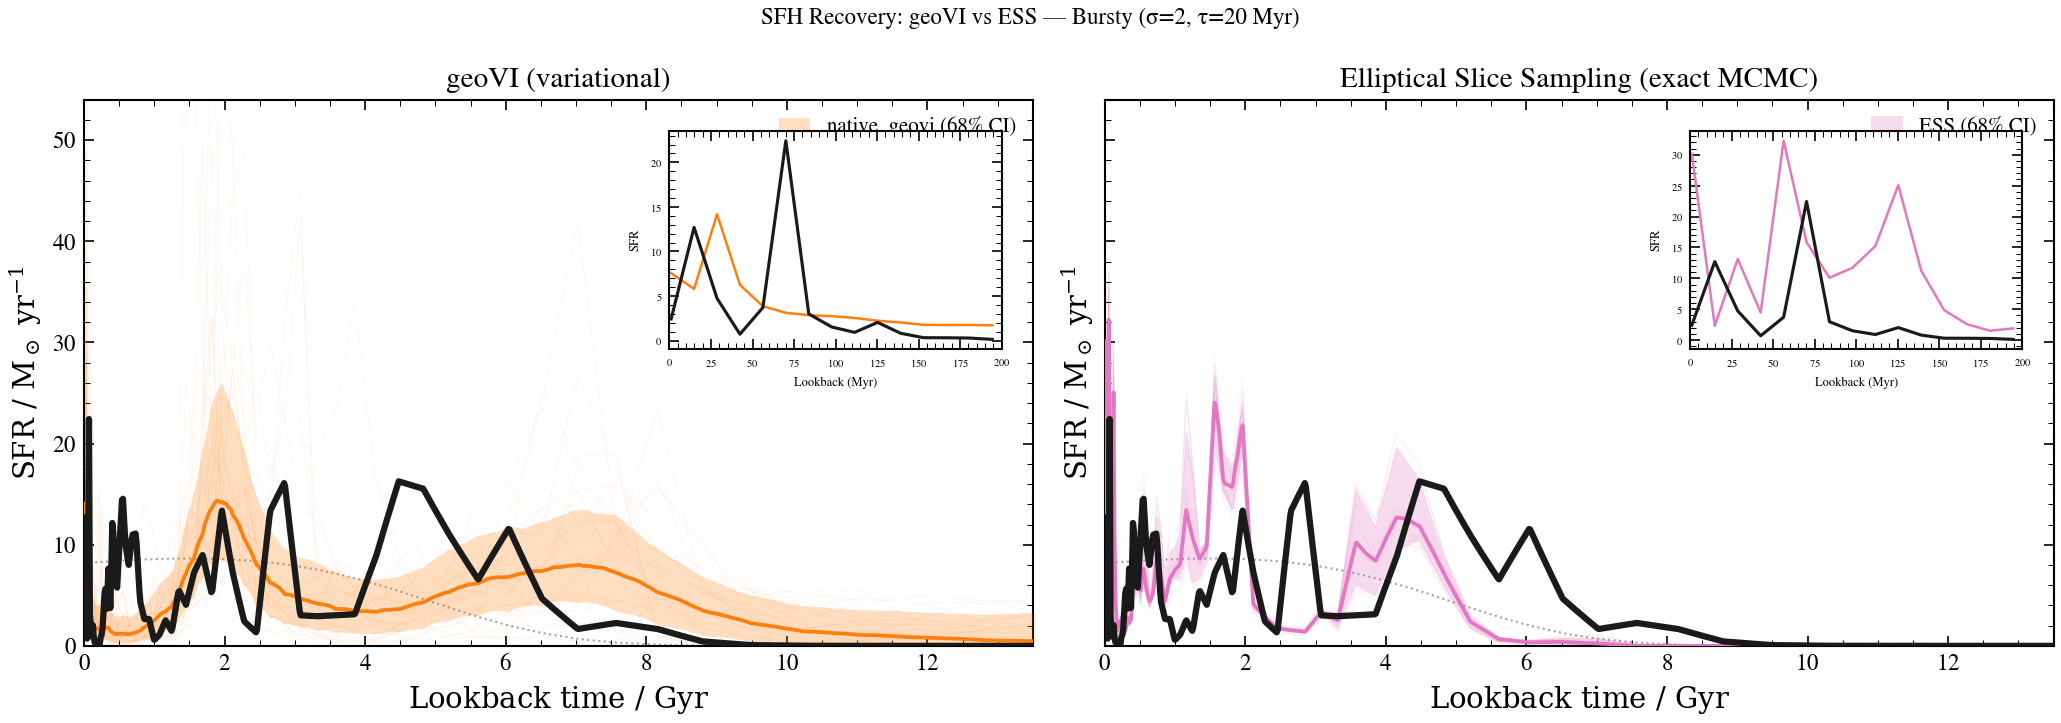

In [11]:
# --- FIGURE 4: geoVI vs ESS SFH recovery (Bursty regime) ---
fig, (ax_gv, ax_ess) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

bursty_true_p = regime_data["Bursty"]["params"]

plot_sfh(
    model_stoch,
    regime_results["Bursty"],
    true_params=bursty_true_p,
    ax=ax_gv,
    color=COLORS["geovi"],
    label="vi",
    method="geoVI",
    show_mean_sfh=True,
)
ax_gv.set_title("geoVI (variational)")

plot_sfh(
    model_stoch,
    result_ess,
    true_params=bursty_true_p,
    ax=ax_ess,
    color=COLORS["ess"],
    label="ESS",
    method="ESS",
    show_mean_sfh=True,
)
ax_ess.set_title("Elliptical Slice Sampling (exact MCMC)")

fig.suptitle("SFH Recovery: geoVI vs ESS — Bursty (σ=2, τ=20 Myr)", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig04_ess_vs_geovi_sfh.png"), dpi=150, bbox_inches="tight")
plt.show()

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered 

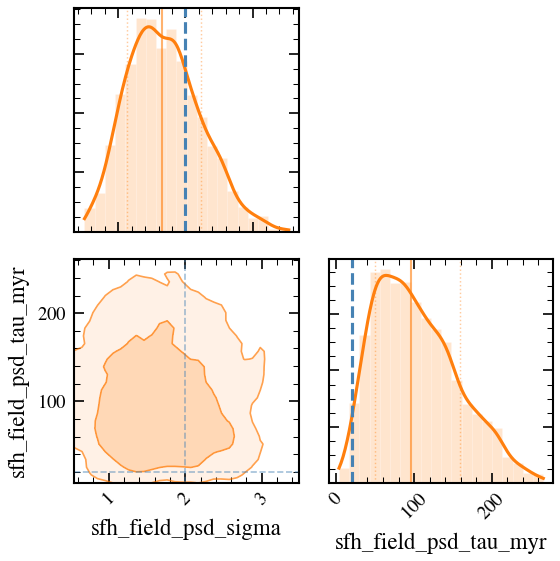

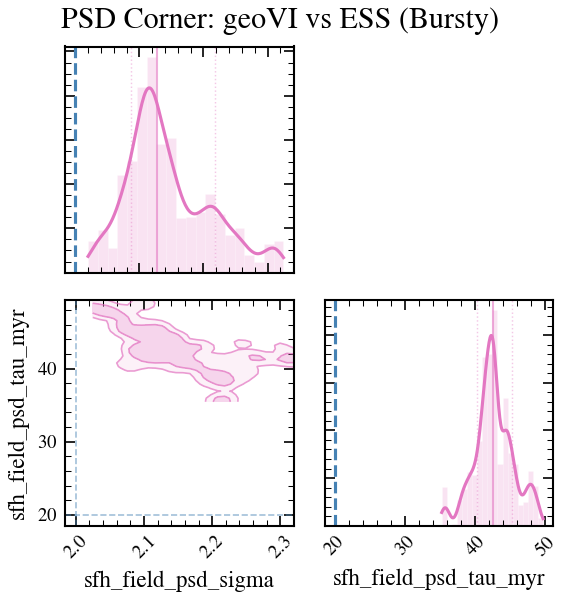

In [12]:
# Corner: PSD parameters — geoVI vs ESS
fig = plot_corner_comparison(
    [regime_results["Bursty"], result_ess],
    labels=["geoVI", "ESS"],
    colors=[COLORS["geovi"], COLORS["ess"]],
    truths=bursty_true_p,
    params=["sfh_field_psd_sigma", "sfh_field_psd_tau_myr"],
)
if fig is not None:
    fig.suptitle("PSD Corner: geoVI vs ESS (Bursty)", y=1.02)
    plt.savefig(
        os.path.join(FIGDIR, "fig04b_ess_vs_geovi_corner.png"),
        dpi=150,
        bbox_inches="tight",
    )
plt.show()

In [13]:
# Convergence comparison
print(
    convergence_table(
        {"geoVI (Bursty)": regime_results["Bursty"], "ESS (Bursty)": result_ess},
        verbose=True,
    )
)

Method           ESS min  ESS med   Accept   Diverg     Status
--------------------------------------------------------------
geoVI (Bursty)      1696     2000        —        —         OK
ESS (Bursty)           3        9        —        —       WARN

Warnings:
  [ESS (Bursty)] Low ESS: 10/19 params below 100 (min ESS = 3 for dust_tau_bc)
  [ESS (Bursty)] Median ESS = 9 < 400 target — consider more samples
{'geoVI (Bursty)': {'ess_min': np.float64(1696.03442654844), 'ess_median': 2000.0, 'n_params_low_ess': 0, 'converged': True, 'warnings': []}, 'ESS (Bursty)': {'ess_min': np.float64(3.3146103733910555), 'ess_median': 8.589913782851177, 'n_params_low_ess': 10, 'converged': False, 'warnings': ['Low ESS: 10/19 params below 100 (min ESS = 3 for dust_tau_bc)', 'Median ESS = 9 < 400 target — consider more samples']}}


## The Wrong Model Trap

A parametric model (no GP) can fit the photometry perfectly — χ² ≈ 1 —
but systematically miss burst features in the SFH. The SED fit looks fine
because broadband photometry averages over timescales shorter than ~100 Myr.

In [14]:
# Fit the "Bursty" regime mock with a PARAMETRIC model
spec_param = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)
model_param = Model(spec_param, ssp_data, observation=obs_spec)

bursty_true = regime_data["Bursty"]["params"]
bursty_mock = model_stoch.mock_spectrum(
    bursty_true,
    WAVE_OBS,
    snr=30.0,
    key=jax.random.PRNGKey(999),
)

# Fit with parametric
fitter_wrong = Fitter(model_param, bursty_mock.flux_obs, bursty_mock.noise)
_ = fitter_wrong.run("map", n_steps=500, verbose=False)
result_wrong = fitter_wrong.run(
    "vi",
    n_iterations=15,
    n_samples=6,
    n_seeds=3,
    n_posterior_samples=2000,
    verbose=False,
)

<local>/Projects/diffsed/src/tengri/core/model.py:466: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2134: UserWarning: Seeds disagree: H = 185.1 ± 20.0 (CV=11%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_native_vi(


<local>/Projects/diffsed/src/tengri/inference/fitter.py:2134: UserWarning: Parameters near bounds: dust_tau_bc, sfh_tsnorm_peak_lbt_gyr. Consider widening the prior.
  return self._run_native_vi(


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_37684/665938130.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


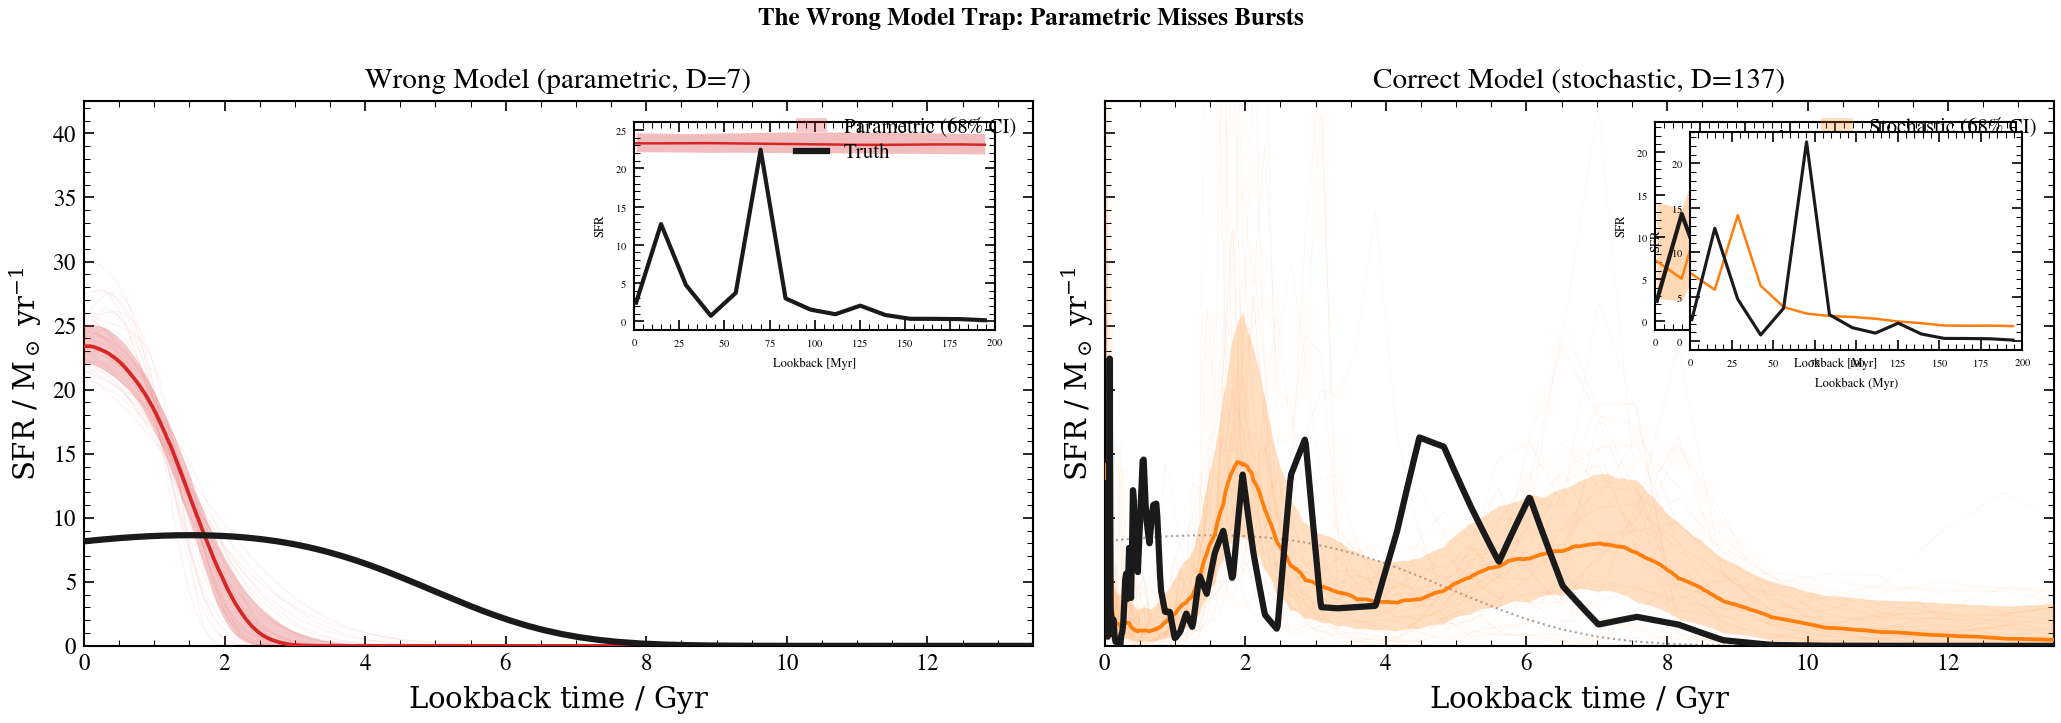

In [15]:
# --- FIGURE 5: Wrong vs correct model (1×2) ---
fig, (ax_wrong, ax_right) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_sfh(
    model_param,
    result_wrong,
    true_params=bursty_true,
    ax=ax_wrong,
    color=COLORS["model"],
    label="Parametric",
    method="MAP",
)
ax_wrong.set_title("Wrong Model (parametric, D=7)")

plot_sfh(
    model_stoch,
    regime_results["Bursty"],
    true_params=bursty_true,
    ax=ax_right,
    color=COLORS["geovi"],
    label="Stochastic",
    method="geoVI",
    show_mean_sfh=True,
)
ax_right.set_title("Correct Model (stochastic, D=137)")

# 200 Myr insets with truth + posterior CI
sfh_bursty = model_stoch.predict_sfh(bursty_true)
t_gyr_b = np.array(sfh_bursty["t_gyr"])
sfr_full_b = np.array(sfh_bursty["sfr_full"])
mask_200 = t_gyr_b < 0.2
t_myr = t_gyr_b[mask_200] * 1e3

inset_data = [
    (ax_wrong, result_wrong, model_param, "sfr_mean", COLORS["model"]),
    (ax_right, regime_results["Bursty"], model_stoch, "sfr_full", COLORS["geovi"]),
]
for ax_panel, res, mod, sfr_key, color in inset_data:
    inset = ax_panel.inset_axes([0.58, 0.58, 0.38, 0.38])
    if res.samples is not None and np.any(mask_200):
        n_draw = min(50, len(next(iter(res.samples.values()))))
        sfh_draws = []
        for j in range(n_draw):
            s_j = {k: res.samples[k][j] for k in res.samples}
            sfh_j = mod.predict_sfh(s_j)
            sfh_draws.append(np.array(sfh_j[sfr_key])[mask_200])
        sfh_arr = np.array(sfh_draws)
        lo, hi = np.percentile(sfh_arr, [16, 84], axis=0)
        med = np.median(sfh_arr, axis=0)
        inset.fill_between(t_myr, lo, hi, color=color, alpha=0.3, lw=0)
        inset.plot(t_myr, med, color=color, lw=1.2)
    inset.plot(t_myr, sfr_full_b[mask_200], color=COLORS["truth"], lw=2, zorder=10)
    inset.set_xlabel("Lookback [Myr]", fontsize=6)
    inset.set_ylabel("SFR", fontsize=6)
    inset.tick_params(labelsize=5)
    inset.set_xlim(0, 200)

fig.suptitle("The Wrong Model Trap: Parametric Misses Bursts", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig05_wrong_model_trap.png"), dpi=150, bbox_inches="tight")
plt.show()

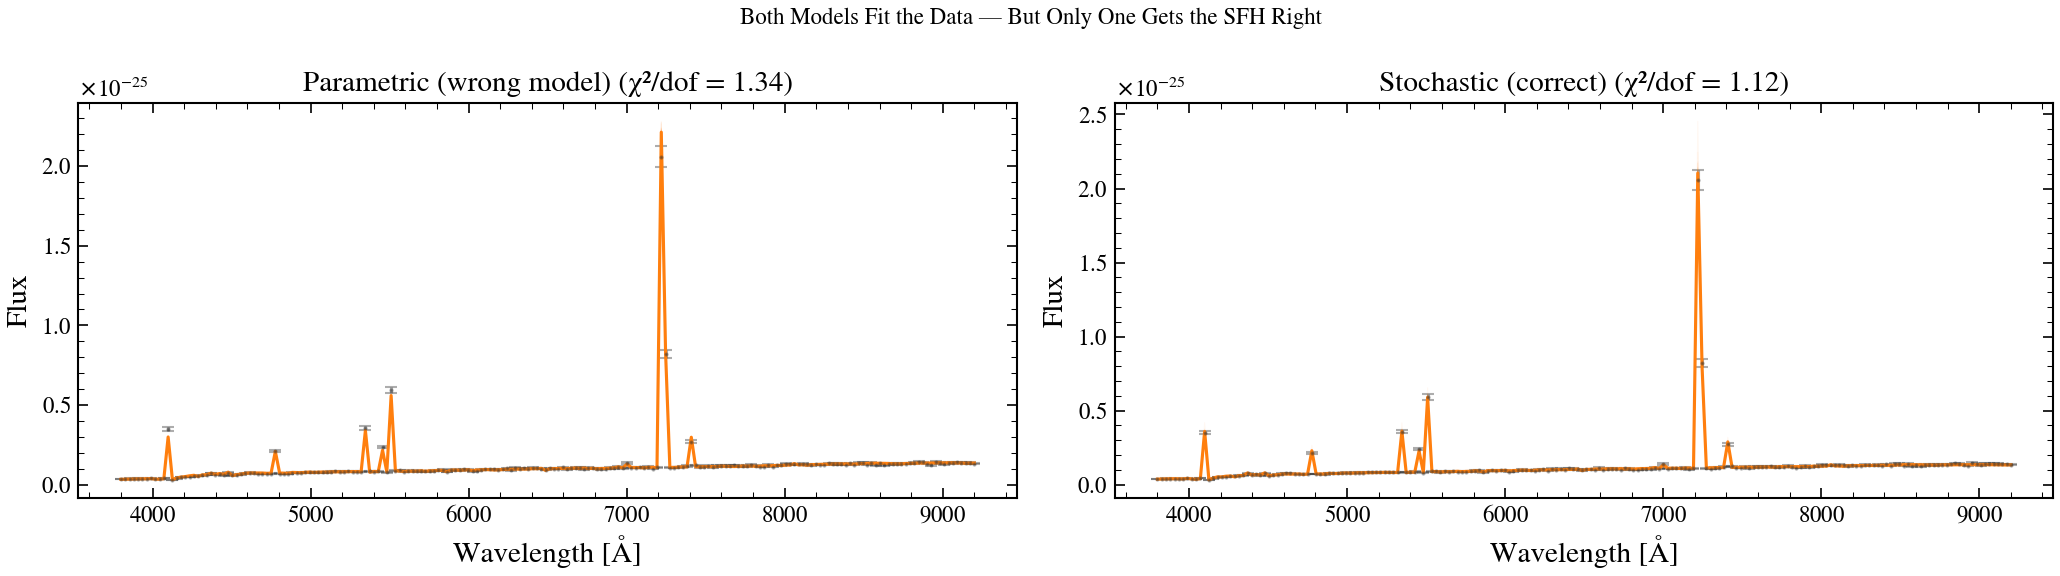

In [16]:
# --- FIGURE 6: Both models fit the data (PPC) ---
fig, (ax_wrong, ax_right) = plt.subplots(1, 2, figsize=(14, 4))

for ax, res, mod, title in [
    (ax_wrong, result_wrong, model_param, "Parametric (wrong model)"),
    (ax_right, regime_results["Bursty"], model_stoch, "Stochastic (correct)"),
]:
    draws = []
    for i in range(30):
        idx = i % len(res.samples[list(res.samples.keys())[0]])
        p = {k: v[idx] for k, v in res.samples.items()}
        draws.append(np.array(mod.predict_spectrum(p)))
    draws = np.array(draws)
    med = np.median(draws, axis=0)

    ax.errorbar(
        np.array(WAVE_OBS),
        np.array(bursty_mock.flux_obs),
        yerr=np.array(bursty_mock.noise),
        fmt=".",
        ms=2,
        color=COLORS["data"],
        alpha=0.4,
    )
    for d in draws:
        ax.plot(np.array(WAVE_OBS), d, color=COLORS["geovi"], alpha=0.05, lw=0.5)
    ax.plot(np.array(WAVE_OBS), med, color=COLORS["geovi"], lw=1.5)

    chi2 = np.sum(
        ((np.array(bursty_mock.flux_obs) - med) / np.array(bursty_mock.noise)) ** 2
    ) / len(med)
    ax.set_title(f"{title} (χ²/dof = {chi2:.2f})")
    ax.set_xlabel("Wavelength [Å]")
    ax.set_ylabel("Flux")

fig.suptitle("Both Models Fit the Data — But Only One Gets the SFH Right", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig06_ppc_both_models.png"), dpi=150, bbox_inches="tight")
plt.show()

### Quantitative bias from wrong model

In [17]:
# Compare derived quantities from parametric (wrong) vs stochastic (right) model
# Compute SFH-derived quantities from posterior draws
def _derived_quantities(model, result, n_draws=100):
    """Compute log M*, SFR_100, SFR_10 from posterior draws."""
    log_mstar, sfr_100, sfr_10 = [], [], []
    n_samples = len(result.samples[next(iter(result.samples.keys()))])
    for i in range(min(n_draws, n_samples)):
        p = {k: v[i] for k, v in result.samples.items()}
        sfh = model.predict_sfh(p)
        t_yr = np.array(sfh["t_gyr"]) * 1e9
        sfr = np.array(sfh.get("sfr_full", sfh.get("sfr_mean")))
        # Stellar mass: integral of SFR (trapezoidal)
        dt = np.abs(np.diff(t_yr))
        sfr_mid = 0.5 * (sfr[:-1] + sfr[1:])
        mstar = np.sum(sfr_mid * dt)
        log_mstar.append(np.log10(max(mstar, 1e-30)))
        # SFR averaged over last 100 Myr and 10 Myr
        t_gyr = np.array(sfh["t_gyr"])
        mask_100 = t_gyr < 0.1
        mask_10 = t_gyr < 0.01
        sfr_100.append(float(np.mean(sfr[mask_100])) if np.any(mask_100) else 0.0)
        sfr_10.append(float(np.mean(sfr[mask_10])) if np.any(mask_10) else 0.0)
    return {
        "log M*": np.array(log_mstar),
        "SFR_100": np.array(sfr_100),
        "SFR_10": np.array(sfr_10),
    }


# Truth
sfh_truth = model_stoch.predict_sfh(bursty_true)
t_truth_yr = np.array(sfh_truth["t_gyr"]) * 1e9
sfr_truth = np.array(sfh_truth["sfr_full"])
dt_truth = np.abs(np.diff(t_truth_yr))
sfr_mid_truth = 0.5 * (sfr_truth[:-1] + sfr_truth[1:])
mstar_truth = np.sum(sfr_mid_truth * dt_truth)
t_gyr_truth = np.array(sfh_truth["t_gyr"])
truth_derived = {
    "log M*": np.log10(max(mstar_truth, 1e-30)),
    "SFR_100": float(np.mean(sfr_truth[t_gyr_truth < 0.1])),
    "SFR_10": float(np.mean(sfr_truth[t_gyr_truth < 0.01])),
}

dq_wrong = _derived_quantities(model_param, result_wrong)
dq_right = _derived_quantities(model_stoch, bursty_res)

print(f"\n{'Quantity':<12s} {'Truth':>12s} {'Parametric':>14s} {'Stochastic':>14s}")
print("-" * 56)
for qty_name in ["log M*", "SFR_100", "SFR_10"]:
    truth_val = truth_derived[qty_name]
    wrong_med = np.median(dq_wrong[qty_name])
    right_med = np.median(dq_right[qty_name])
    wrong_lo, wrong_hi = np.percentile(dq_wrong[qty_name], [16, 84])
    right_lo, right_hi = np.percentile(dq_right[qty_name], [16, 84])
    print(
        f"  {qty_name:<10s} {truth_val:12.3f}"
        f" {wrong_med:8.3f} [{wrong_lo:.2f},{wrong_hi:.2f}]"
        f" {right_med:8.3f} [{right_lo:.2f},{right_hi:.2f}]"
    )


Quantity            Truth     Parametric     Stochastic
--------------------------------------------------------
  log M*           10.741   10.548 [10.53,10.56]   10.835 [10.79,10.86]
  SFR_100           6.408   23.177 [22.05,24.72]    6.747 [5.57,8.46]
  SFR_10            2.439   23.232 [22.11,24.82]    7.600 [3.68,12.55]


## Takeaway

A good spectral fit (chi-squared ~ 1) does **not** guarantee correct physical
interpretation. Parametric models smooth over burst features that the
stochastic model captures. Always use the stochastic model when burstiness
matters — especially for recent SFR, sSFR, and emission line predictions.